<a href="https://colab.research.google.com/github/Deangr-econ/Quant_methods_project/blob/main/VAR_GPRD_OIL_GAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from statsmodels.tsa.api import VAR
import matplotlib.pyplot as plt
import pandas_datareader.data as web
import statsmodels.api as sm

In [ ]:
gpr = pd.read_stata("/content/data_gpr_daily_recent.dta")

# 1. Load GPR data
gpr = pd.read_stata("/content/data_gpr_daily_recent.dta")
gpr['date'] = pd.to_datetime(gpr['date'])
gpr = gpr.set_index('date')

# 2. Download Energy Futures
raw_energy = yf.download(
    tickers=['CL=F', 'NG=F'],
    start='1990-01-01',
    auto_adjust=True
)['Close']

# Strip timezone if present
raw_energy.index = pd.to_datetime(raw_energy.index).tz_localize(None)
gpr.index = pd.to_datetime(gpr.index).tz_localize(None)

# 3. Trim to first valid date of NG=F and merge
tidx = raw_energy['NG=F'].first_valid_index()
data = raw_energy.loc[tidx:].join(gpr['GPRD'], how='inner').dropna()
data.columns = ['OIL_PRICE', 'GAS_PRICE', 'GPRD']

# 4. Clean non-positive crude anomaly (2020-04-20)
data['OIL_PRICE'] = data['OIL_PRICE'].mask(data['OIL_PRICE'] <= 0).ffill()

# 5. Build explicit stationary DataFrame for VAR estimation
var_df = pd.DataFrame(index=data.index)
var_df['OIL'] = np.log(data['OIL_PRICE']).diff()
var_df['GAS'] = np.log(data['GAS_PRICE']).diff()

# Use log-difference for GPR (clipped to avoid log(0))
var_df['GPRD'] = np.log(data['GPRD'].clip(lower=1e-5)).diff()

# Drop initial NaN created by differencing
var_df = var_df.dropna()

[*********************100%***********************]  2 of 2 completed


In [ ]:
model = VAR(var_df)
# Evaluate lags 1 through 15
lag_order = model.select_order(maxlags=20)

# Choose lag by AIC (more flexible) or BIC (more parsimonious)
optimal_lag = lag_order.bic
print(f"Optimal lag according to AIC: {optimal_lag}")

# Fit the VAR model with the selected lag
results = model.fit(optimal_lag)


# Does GPR predict Oil returns?
gc_oil = results.test_causality('OIL', ['GPRD'], kind='f')
print("Granger Causality (GPR -> Oil):")
print(gc_oil.summary())

# Does GPR predict Gas returns?
gc_gas = results.test_causality('GAS', ['GPRD'], kind='f')
print("\nGranger Causality (GPR -> Gas):")
print(gc_gas.summary())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/base/tsa_model.py:480: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g., forecasting.
  self._init_dates(dates, freq)


Optimal lag according to AIC: 5
Granger Causality (GPR -> Oil):
Granger causality F-test. H_0: GPRD does not Granger-cause OIL. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value          df         
----------------------------------------------------------
        0.3166          2.215   0.903 (5, np.int64(19545))
----------------------------------------------------------

Granger Causality (GPR -> Gas):
Granger causality F-test. H_0: GPRD does not Granger-cause GAS. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value          df         
----------------------------------------------------------
         2.004          2.215   0.075 (5, np.int64(19545))
----------------------------------------------------------


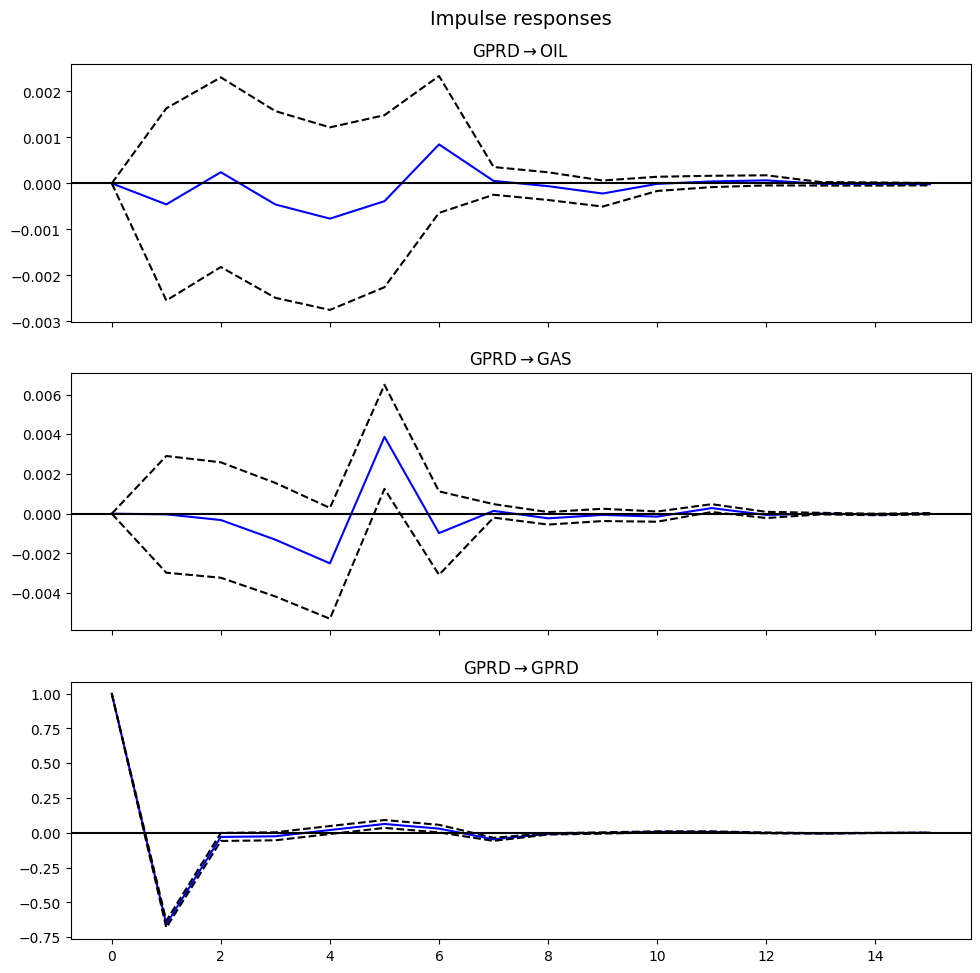

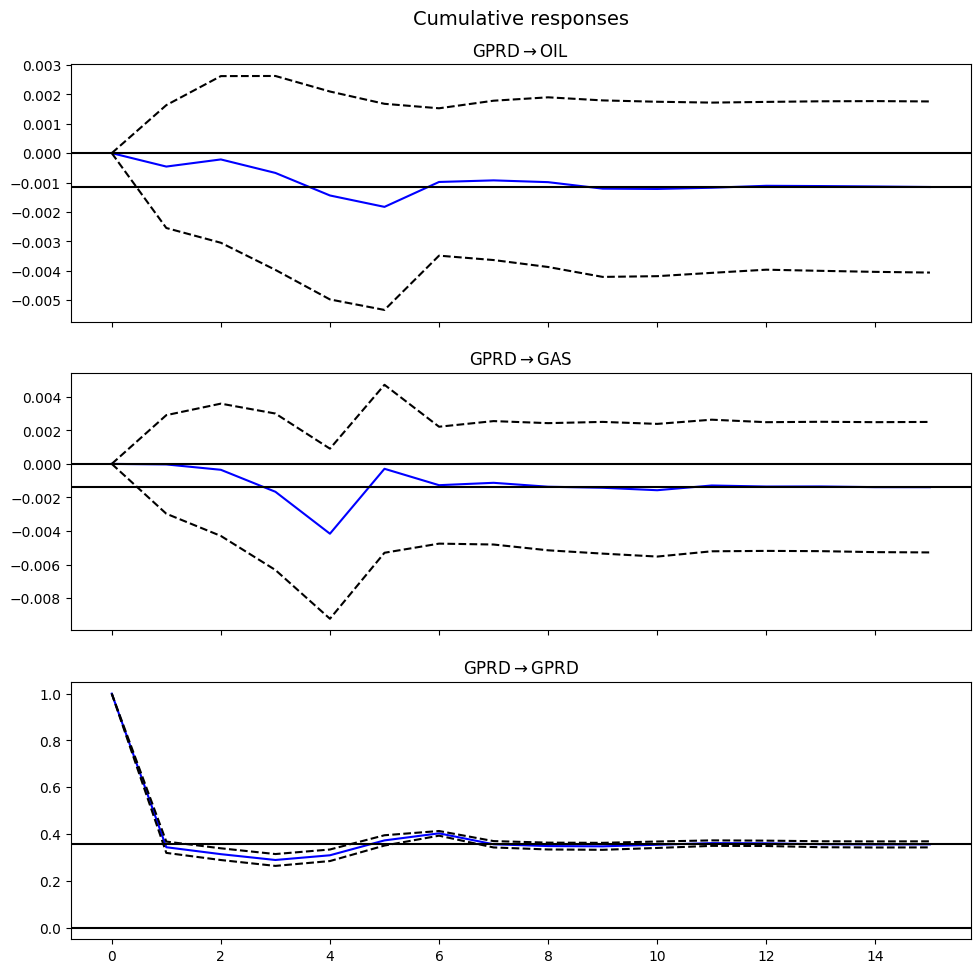

In [ ]:
# Compute orthogonalized IRFs (default uses Cholesky ordering based on DataFrame column order)
irf = results.irf(periods=15)

# Plot responses to a GPR shock
fig = irf.plot(impulse='GPRD')
plt.show()

# Cumulative IRF (to see net directional impact over time)
fig_cum = irf.plot_cum_effects(impulse='GPRD')
plt.show()

FEVD for OIL
          OIL       GAS      GPRD
0    1.000000  0.000000  0.000000
1    0.999801  0.000171  0.000028
2    0.999641  0.000323  0.000036
3    0.999606  0.000331  0.000064
4    0.999135  0.000723  0.000141
5    0.999097  0.000742  0.000161
6    0.999001  0.000742  0.000256
7    0.999001  0.000742  0.000257
8    0.998999  0.000744  0.000257
9    0.998992  0.000744  0.000264

FEVD for GAS
          OIL       GAS      GPRD
0    0.031459  0.968541  0.000000
1    0.032722  0.967278  0.000000
2    0.032778  0.967215  0.000007
3    0.032850  0.967028  0.000122
4    0.033100  0.966358  0.000542
5    0.033005  0.965452  0.001542
6    0.033003  0.965391  0.001606
7    0.033003  0.965390  0.001607
8    0.033005  0.965384  0.001611
9    0.033007  0.965382  0.001611

FEVD for GPRD
          OIL       GAS      GPRD
0    0.000000  0.000168  0.999832
1    0.000169  0.000224  0.999607
2    0.000169  0.000344  0.999487
3    0.000262  0.000447  0.999291
4    0.000300  0.000503  0.999197
5    0

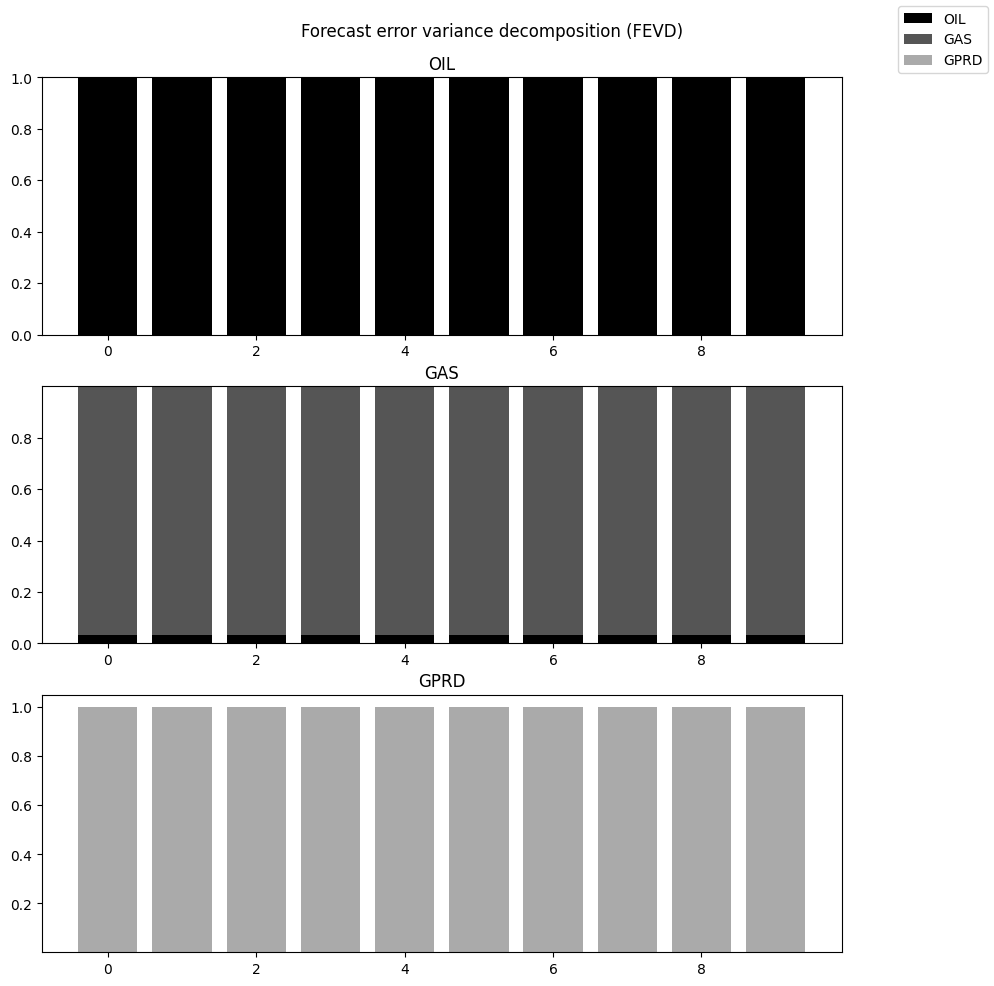

In [ ]:
fevd = results.fevd(10)
print(fevd.summary())
fevd.plot()
plt.show()

In [ ]:
p = 5
cols = ['OIL', 'GAS', 'GPRD']

# Build lag matrix
df_lags = pd.concat([var_df[cols].shift(i).add_suffix(f'_lag{i}') for i in range(1, p + 1)], axis=1)

X = sm.add_constant(df_lags).dropna()
y_gas = var_df['GAS'].loc[X.index]

# Fit with HC3 robust covariance
model_gas_robust = sm.OLS(y_gas, X).fit(cov_type='HC3')

# Test joint significance of GPR lags
gpr_lags = [col for col in X.columns if 'GPR' in col]
gpr_hypothesis = [f"{col} = 0" for col in gpr_lags]

robust_test = model_gas_robust.wald_test(gpr_hypothesis)

print("--- Robust Granger Causality (GPR -> GAS) ---")
print(f"Wald Chi2: {robust_test.statistic:.4f}")
print(f"p-value:   {robust_test.pvalue:.4f}")

--- Robust Granger Causality (GPR -> GAS) ---
Wald Chi2: 10.7931
p-value:   0.0556


In [ ]:
model_gas_robust.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    GAS   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     2.427
Date:                Thu, 17 Sep 2026   Prob (F-statistic):            0.00158
Time:                        08:49:38   Log-Likelihood:                 12042.
No. Observations:                6531   AIC:                        -2.405e+04
Df Residuals:                    6515   BIC:                        -2.394e+04
Df Model:                          15                                         
Covariance Type:                  HC3                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -8.611e-05      0.000     -0.181      0.857      -0.001       0.001
OIL_lag1      -0.0370      0.020     -1.894      0.058      -0.075       0.001
GAS_lag1      -0.0665      0.021     -3.211      0.001      -0.107      -0.026
GPRD_lag1  -3.287e-05      0.001     -0.022      0.982      -0.003       0.003
OIL_lag2       0.0021      0.020      0.108      0.914      -0.037       0.041
GAS_lag2       0.0187      0.024      0.765      0.444      -0.029       0.067
GPRD_lag2     -0.0004      0.002     -0.199      0.842      -0.004       0.003
OIL_lag3       0.0168      0.020      0.837      0.403      -0.022       0.056
GAS_lag3      -0.0117      0.025     -0.465      0.642      -0.061       0.038
GPRD_lag3     -0.0016      0.002     -0.819      0.413      -0.005       0.002
OIL_lag4      -0.0245      0.018     -1.326      0.185      -0.061       0.012
GAS_lag4       0.0048      0.019      0.256      0.798      -0.032       0.042
GPRD_lag4     -0.0036      0.002     -2.168      0.030      -0.007      -0.000
OIL_lag5       0.0125      0.018      0.708      0.479      -0.022       0.047
GAS_lag5      -0.0437      0.018     -2.498      0.012      -0.078      -0.009
GPRD_lag5      0.0012      0.001      0.867      0.386      -0.002       0.004
==============================================================================
Omnibus:                     1564.402   Durbin-Watson:                   2.002
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            83002.588
Skew:                          -0.221   Prob(JB):                         0.00
Kurtosis:                      20.459   Cond. No.                         40.5
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

In [ ]:
robust_test

<class 'statsmodels.stats.contrast.ContrastResults'>
<Wald test (chi2): statistic=10.793056334226687, p-value=0.05564100852899325, df_denom=5>

<>:30: SyntaxWarning: invalid escape sequence '\m'
<>:30: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_2174/1645034556.py:30: SyntaxWarning: invalid escape sequence '\m'
  label=f"Normal ($\mu=0, \sigma={std:.3f}$)",


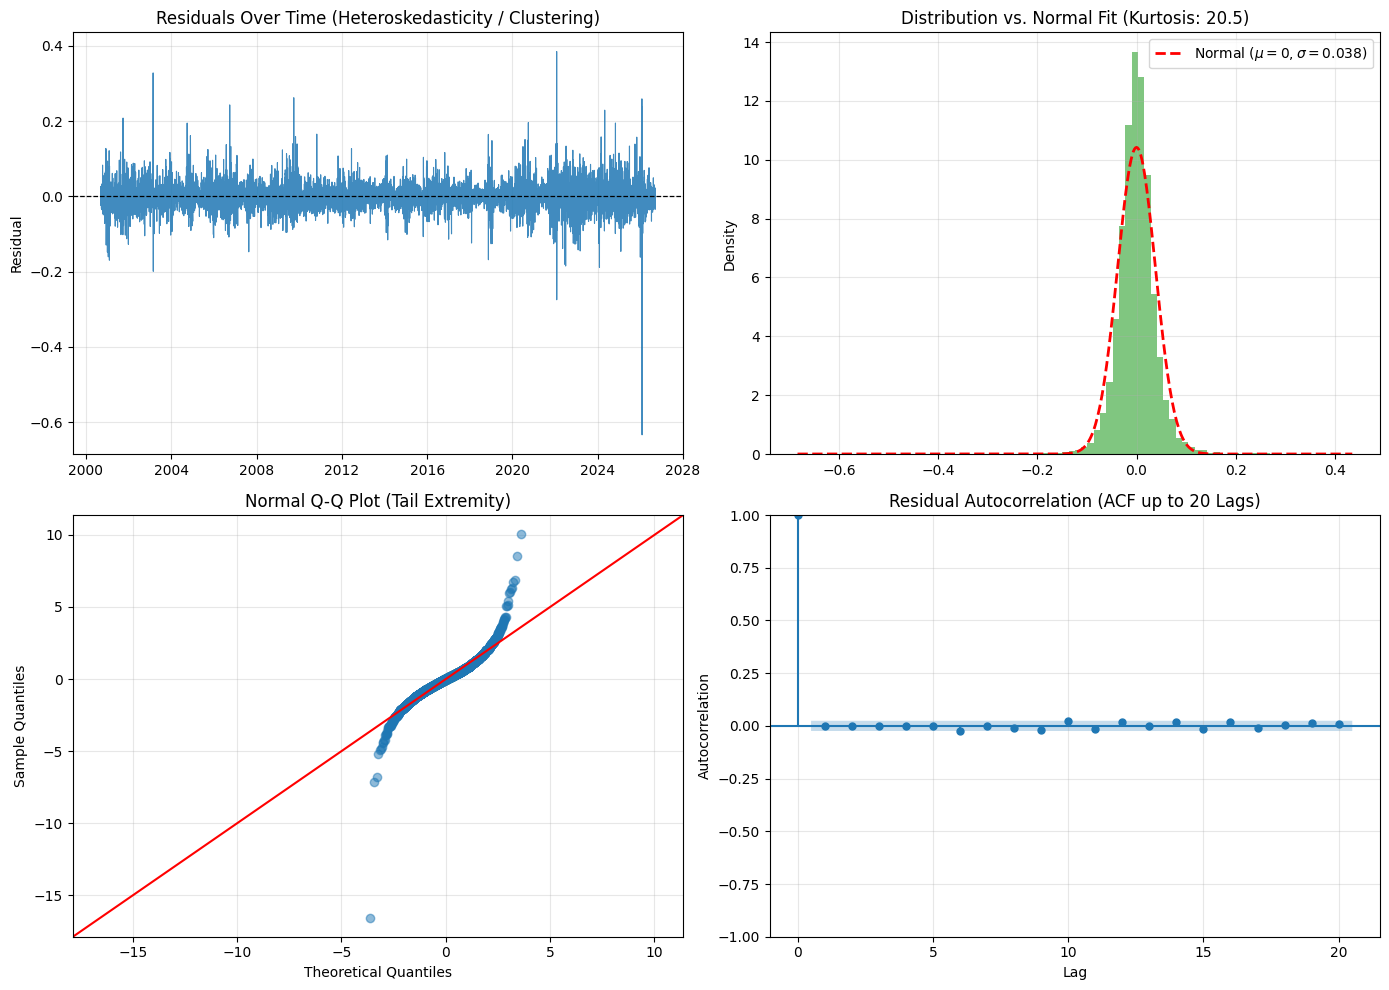

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import statsmodels.api as sm

# Extract residuals from the fitted robust model
resid = model_gas_robust.resid

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Residuals Over Time (Volatility Clustering)
axes[0, 0].plot(resid.index, resid, color="#1f77b4", lw=0.8, alpha=0.85)
axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=0.9)
axes[0, 0].set_title("Residuals Over Time (Heteroskedasticity / Clustering)")
axes[0, 0].set_ylabel("Residual")
axes[0, 0].grid(True, alpha=0.3)

# 2. Histogram vs. Theoretical Normal Distribution
count, bins, _ = axes[0, 1].hist(
    resid, bins=80, density=True, alpha=0.6, color="#2ca02c", edgecolor="none"
)
mu, std = stats.norm.fit(resid)
xmin, xmax = axes[0, 1].get_xlim()
x_pdf = np.linspace(xmin, xmax, 500)
axes[0, 1].plot(
    x_pdf,
    stats.norm.pdf(x_pdf, mu, std),
    "r--",
    lw=2,
    label=f"Normal ($\mu=0, \sigma={std:.3f}$)",
)
axes[0, 1].set_title(
    f"Distribution vs. Normal Fit (Kurtosis: {stats.kurtosis(resid, fisher=False):.1f})"
)
axes[0, 1].set_ylabel("Density")
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. Quantile-Quantile (Q-Q) Plot (Fat Tails)
sm.qqplot(resid, line="45", fit=True, ax=axes[1, 0], color="#1f77b4", alpha=0.5)
axes[1, 0].set_title("Normal Q-Q Plot (Tail Extremity)")
axes[1, 0].grid(True, alpha=0.3)

# 4. Autocorrelation Function (ACF) of Residuals
sm.graphics.tsa.plot_acf(resid, lags=20, ax=axes[1, 1], alpha=0.05)
axes[1, 1].set_title("Residual Autocorrelation (ACF up to 20 Lags)")
axes[1, 1].set_xlabel("Lag")
axes[1, 1].set_ylabel("Autocorrelation")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf

# 1. Fetch fresh un-differenced raw closing prices
raw_prices = yf.download(
    tickers=['CL=F', 'NG=F'],
    start='2025-09-01',
    end='2026-04-01',
    auto_adjust=True,
)['Close']

# Standardize index formatting
raw_prices.index = pd.to_datetime(raw_prices.index).tz_localize(None)

# 2. Build aligned inspection DataFrame centered on the target date
target_date = pd.to_datetime('2026-01-29')

inspect_df = pd.DataFrame(index=model_gas_robust.resid.index)
inspect_df['Gas_Price ($)'] = raw_prices['NG=F']
inspect_df['Oil_Price ($)'] = raw_prices['CL=F']
inspect_df['Gas_Return'] = var_df['GAS']
inspect_df['Gas_Residual'] = model_gas_robust.resid
inspect_df['GPRD_Diff'] = var_df['GPRD']

# 3. Locate target date row index and slice 50 observations before & after
target_idx = inspect_df.index.get_indexer([target_date], method='nearest')[0]
start_idx = max(0, target_idx - 50)
end_idx = min(len(inspect_df), target_idx + 51)

window_100 = inspect_df.iloc[start_idx:end_idx]

# 4. Print clean tabular output
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')

print(f'Observations centered on {inspect_df.index[target_idx].date()}:')
print(window_100)

[*********************100%***********************]  2 of 2 completed

Observations centered on 2026-01-29:
            Gas_Price ($)  Oil_Price ($)  Gas_Return  Gas_Residual  GPRD_Diff
2025-11-14         4.5660        60.0900     -0.0174       -0.0155     0.1419
2025-11-17         4.3610        59.9100     -0.0459       -0.0463     0.3119
2025-11-18         4.3710        60.7400      0.0023       -0.0004    -0.3193
2025-11-19         4.5500        59.4400      0.0401        0.0417    -0.3121
2025-11-20         4.4740        59.1400     -0.0168       -0.0128     0.3547
2025-11-21         4.5800        58.0600      0.0234        0.0207     0.6536
2025-11-24         4.5490        58.8400     -0.0068       -0.0082     0.0609
2025-11-25         4.4240        57.9500     -0.0279       -0.0290     0.0825
2025-11-26         4.5580        58.6500      0.0298        0.0329    -0.4640
2025-11-28         4.8500        58.5500      0.0621        0.0657     0.2464
2025-12-01         4.9210        59.3200      0.0145        0.0190    -0.0094
2025-12-02         4.8400  